In [1]:
import math

import torch
import torch.nn as nn
from torch import optim
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader

import numpy as np
import matplotlib.pyplot as plt

In [2]:
def generate_star(n_spikes=5, inner_radius=0.4, outer_radius=1.0, n_samples=1000, center=(0, 0)):
    angle_step = np.pi / n_spikes

    vertices = []
    for i in range(2 * n_spikes):
        angle = i * angle_step
        radius = outer_radius if i % 2 == 0 else inner_radius

        x = radius * np.cos(angle) + center[0]
        y = radius * np.sin(angle) + center[1]
        vertices.append([x, y])

    vertices.append(vertices[0])
    vertices = np.array(vertices)

    sampled_points = []

    for i in range(len(vertices) - 1):
        start_point = vertices[i]
        end_point = vertices[i + 1]

        for t in np.linspace(0, 1, n_samples // (len(vertices) - 1)):
            point = (1 - t) * start_point + t * end_point
            sampled_points.append(point)

    return np.array(sampled_points)

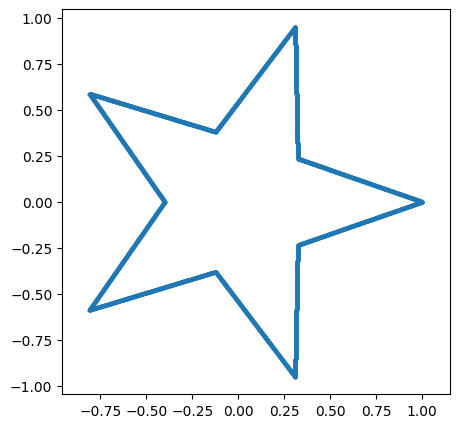

In [3]:
s = generate_star(n_samples=5000)

plt.figure(figsize=(5, 5))
plt.scatter(s[:, 0], s[:, 1], s=3)
plt.axis("equal")
plt.show()

In [ ]:
class Config:
    beta_min = 0.1
    beta_max = 10.0

    lr = 1e-3
    epochs = 3000
    batch_size = 512
    hidden_dim = 256
    num_timesteps = 2000
    data_samples = 5000

In [15]:
class ScoreModel(nn.Module):
    def __init__(self, config):
        super().__init__()

        self.config = config

        self.time_embed = nn.Sequential(
            nn.Linear(1, config.hidden_dim),
            nn.ReLU(),
            nn.Linear(config.hidden_dim, config.hidden_dim),
            nn.ReLU()
        )

        self.net = nn.Sequential(
            nn.Linear(2 + config.hidden_dim, config.hidden_dim),
            nn.ReLU(),
            nn.Linear(config.hidden_dim, config.hidden_dim),
            nn.ReLU(),
            nn.Linear(config.hidden_dim, 2)
        )

    def forward(self, x, t):
        t_embed = self.time_embed(t)
        x_input = torch.cat([x, t_embed], dim=1)

        return self.net(x_input)

In [16]:
# Расписание шума
def beta_t(t, config):
    return config.beta_min + (config.beta_max - config.beta_min) * t

def integral_beta_t(t, config):
    return config.beta_min * t + 0.5 * (config.beta_max - config.beta_min) * t ** 2

# Насколько сохраняется исходная точка
def alpha_t(t, config):
    return torch.exp(-0.5 * integral_beta_t(t, config))

# Сколько шума добавляется
def sigma_t_vp(t, config):
    alpha = alpha_t(t, config)
    return torch.sqrt(1.0 - alpha ** 2)

In [17]:
class VPTrainer():
    def __init__(self, config):
        self.config = config
        self.device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')

        star = generate_star(n_samples=config.data_samples)
        self.data = torch.tensor(star, dtype=torch.float32)

        self.dataset = TensorDataset(self.data)
        self.dataloader = DataLoader(
            self.dataset,
            batch_size=config.batch_size,
            shuffle=True
        )

        self.model = ScoreModel(config).to(self.device)
        self.optimizer = optim.Adam(self.model.parameters(), lr=config.lr)

    def train_epoch(self):
        self.model.train()
        total_loss = 0.0

        for (batch, ) in self.dataloader:
            batch = batch.to(self.device)

            t = torch.rand(batch.shape[0], 1, device=self.device)

            alpha = alpha_t(t, self.config)
            sigma = sigma_t_vp(t, self.config)

            z = torch.randn_like(batch)

            x_t = alpha * batch + sigma * z

            pred_z = self.model(x_t, t)
            # loss = ((sigma * pred_z + z) ** 2).sum(dim=1).mean()
            loss = F.mse_loss(pred_z, z)

            self.optimizer.zero_grad()
            loss.backward()
            self.optimizer.step()

            total_loss += loss.item() * batch.shape[0]

        return total_loss / len(self.data)

    def run(self):
        losses = []

        for epoch in range(self.config.epochs):
            loss = self.train_epoch()
            losses.append(loss)

            if epoch % 100 == 0:
                print(f'Epoch {epoch}, Loss: {loss:.6f}')

        return losses

In [18]:
config = Config()
trainer = VPTrainer(config)

losses = trainer.run()

Epoch 0, Loss: 0.842093
Epoch 100, Loss: 0.256964
Epoch 200, Loss: 0.217426
Epoch 300, Loss: 0.224547
Epoch 400, Loss: 0.221281
Epoch 500, Loss: 0.205740
Epoch 600, Loss: 0.212869
Epoch 700, Loss: 0.212450
Epoch 800, Loss: 0.209228
Epoch 900, Loss: 0.213645
Epoch 1000, Loss: 0.211894
Epoch 1100, Loss: 0.208722
Epoch 1200, Loss: 0.199745
Epoch 1300, Loss: 0.204721
Epoch 1400, Loss: 0.203908
Epoch 1500, Loss: 0.209677
Epoch 1600, Loss: 0.211446
Epoch 1700, Loss: 0.212873
Epoch 1800, Loss: 0.212585
Epoch 1900, Loss: 0.202655
Epoch 2000, Loss: 0.204677
Epoch 2100, Loss: 0.211884
Epoch 2200, Loss: 0.193258
Epoch 2300, Loss: 0.201179
Epoch 2400, Loss: 0.201523
Epoch 2500, Loss: 0.201878
Epoch 2600, Loss: 0.193878
Epoch 2700, Loss: 0.198157
Epoch 2800, Loss: 0.200689
Epoch 2900, Loss: 0.212585


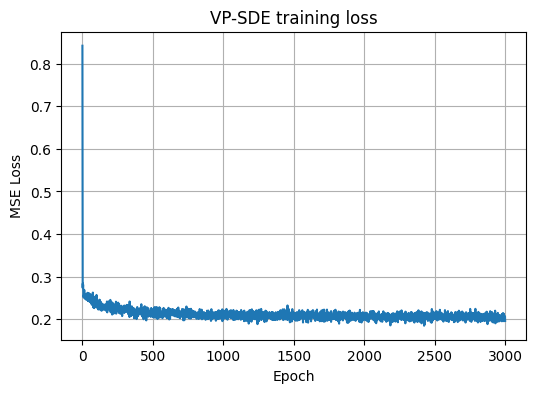

In [19]:
plt.figure(figsize=(6,4))
plt.plot(losses)
plt.title("VP-SDE training loss")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.grid()
plt.show()

In [20]:
def sample_vp_sde(model, config, num_samples=1000):
    device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')
    model.eval()

    with torch.no_grad():
        x = torch.randn(num_samples, 2, device=device)

        dt = 1.0 / config.num_timesteps

        for i in range(config.num_timesteps):
            t_value = 1.0 - i * dt
            t_value = max(t_value, 1e-5)

            t = torch.full((num_samples, 1), t_value, device=device)

            beta = beta_t(t, config)
            sigma = sigma_t_vp(t, config)

            pred_z = model(x, t)

            score = -pred_z / sigma

            drift = 0.5 * beta * x + beta * score
            diffusion = torch.sqrt(beta) * torch.randn_like(x)

            x = x + drift * dt + diffusion * math.sqrt(dt)

        return x.cpu().numpy()

In [21]:
samples = sample_vp_sde(trainer.model, trainer.config, num_samples=3000)

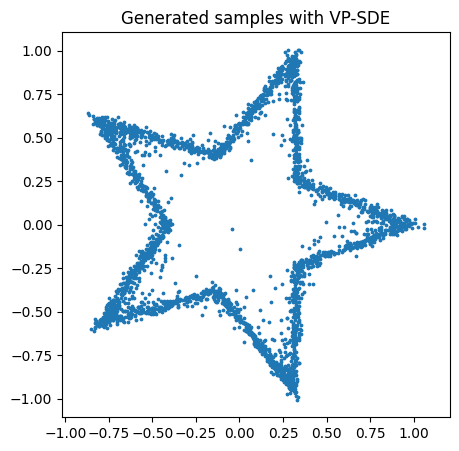

In [22]:
plt.figure(figsize=(5, 5))
plt.scatter(samples[:, 0], samples[:, 1], s=3)
plt.axis("equal")
plt.title("Generated samples with VP-SDE")
plt.show()

In [23]:
class ExperimentConfig:
    beta_min = 0.1
    beta_max = 10.0

    lr = 1e-3
    epochs = 1500
    batch_size = 512
    hidden_dim = 256
    num_timesteps = 1500
    data_samples = 5000

    schedule_type = "linear"      # "linear" или "cosine"
    loss_weight_type = "none"     # "none", "sigma2", "snr", "inverse_sigma2"

    cosine_s = 0.008
    beta_clip = 20.0

In [24]:
def get_alpha_sigma_beta(t, config):
    """
    Возвращает alpha(t), sigma(t), beta(t) для VP-SDE.

    x_t = alpha(t) * x_0 + sigma(t) * z
    """

    if config.schedule_type == "linear":
        beta = config.beta_min + t * (config.beta_max - config.beta_min)

        integral_beta = (
            config.beta_min * t
            + 0.5 * (config.beta_max - config.beta_min) * t ** 2
        )

        alpha_bar = torch.exp(-integral_beta)

    elif config.schedule_type == "cosine":
        s = config.cosine_s

        t_safe = torch.clamp(t, 1e-5, 0.999)

        theta = (t_safe + s) / (1 + s) * math.pi / 2
        theta_0 = s / (1 + s) * math.pi / 2

        alpha_bar = (torch.cos(theta) ** 2) / (math.cos(theta_0) ** 2)
        alpha_bar = torch.clamp(alpha_bar, min=1e-5, max=1.0)

        beta = (math.pi / (1 + s)) * torch.tan(theta)
        beta = torch.clamp(beta, min=1e-5, max=config.beta_clip)

    else:
        raise ValueError(f"Unknown schedule_type: {config.schedule_type}")

    alpha = torch.sqrt(alpha_bar)
    sigma = torch.sqrt(1.0 - alpha_bar)

    sigma = torch.clamp(sigma, min=1e-5)

    return alpha, sigma, beta

In [25]:
def get_loss_weight(t, alpha, sigma, config):
    """
    Возвращает вес для loss в зависимости от времени t.
    """

    if config.loss_weight_type == "none":
        weight = torch.ones_like(t)

    elif config.loss_weight_type == "sigma2":
        # Больше веса на больших шумах
        weight = sigma ** 2

    elif config.loss_weight_type == "snr":
        # SNR = alpha^2 / sigma^2
        # Больше веса на малых шумах, где структура данных ещё хорошо видна
        snr = (alpha ** 2) / (sigma ** 2)
        weight = torch.clamp(snr, max=5.0)

    elif config.loss_weight_type == "inverse_sigma2":
        # Акцент на маленьких шумах, но с ограничением, чтобы loss не взрывался
        weight = 1.0 / (sigma ** 2)
        weight = torch.clamp(weight, max=10.0)

    else:
        raise ValueError(f"Unknown loss_weight_type: {config.loss_weight_type}")

    weight = weight / weight.mean().detach()

    return weight

In [26]:
class ScoreModel(nn.Module):
    def __init__(self, config):
        super().__init__()

        self.config = config

        self.time_embed = nn.Sequential(
            nn.Linear(1, config.hidden_dim),
            nn.ReLU(),
            nn.Linear(config.hidden_dim, config.hidden_dim),
            nn.ReLU()
        )

        self.net = nn.Sequential(
            nn.Linear(2 + config.hidden_dim, config.hidden_dim),
            nn.ReLU(),
            nn.Linear(config.hidden_dim, config.hidden_dim),
            nn.ReLU(),
            nn.Linear(config.hidden_dim, 2)
        )

    def forward(self, x, t):
        t_embed = self.time_embed(t)
        x_input = torch.cat([x, t_embed], dim=1)

        return self.net(x_input)

In [27]:
class VPExperimentTrainer:
    def __init__(self, config):
        self.config = config
        self.device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")

        star = generate_star(n_samples=config.data_samples)
        self.data = torch.tensor(star, dtype=torch.float32)

        self.dataset = TensorDataset(self.data)
        self.dataloader = DataLoader(
            self.dataset,
            batch_size=config.batch_size,
            shuffle=True
        )

        self.model = ScoreModel(config).to(self.device)
        self.optimizer = optim.Adam(self.model.parameters(), lr=config.lr)

    def train_epoch(self):
        self.model.train()
        total_loss = 0.0

        for (batch,) in self.dataloader:
            batch = batch.to(self.device)

            t = torch.rand(batch.shape[0], 1, device=self.device)

            alpha, sigma, beta = get_alpha_sigma_beta(t, self.config)

            z = torch.randn_like(batch)

            x_t = alpha * batch + sigma * z

            pred_z = self.model(x_t, t)

            mse_per_sample = ((pred_z - z) ** 2).sum(dim=1, keepdim=True)

            weight = get_loss_weight(t, alpha, sigma, self.config)

            loss = (weight * mse_per_sample).mean()

            self.optimizer.zero_grad()
            loss.backward()
            self.optimizer.step()

            total_loss += loss.item() * batch.shape[0]

        return total_loss / len(self.data)

    def run(self):
        losses = []

        print(
            f"Training: schedule={self.config.schedule_type}, "
            f"loss_weight={self.config.loss_weight_type}"
        )

        for epoch in range(self.config.epochs):
            loss = self.train_epoch()
            losses.append(loss)

            if epoch % 100 == 0:
                print(f"Epoch {epoch}, Loss: {loss:.6f}")

        return losses

In [28]:
def sample_vp_sde_experiment(model, config, num_samples=3000):
    device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")
    model.eval()

    with torch.no_grad():
        x = torch.randn(num_samples, 2, device=device)

        dt = 1.0 / config.num_timesteps

        for i in range(config.num_timesteps):
            t_value = 1.0 - i * dt
            t_value = max(t_value, 1e-5)

            t = torch.full((num_samples, 1), t_value, device=device)

            alpha, sigma, beta = get_alpha_sigma_beta(t, config)

            pred_z = model(x, t)

            score = -pred_z / sigma

            drift = 0.5 * beta * x + beta * score
            diffusion = torch.sqrt(beta) * torch.randn_like(x)

            x = x + drift * dt + diffusion * math.sqrt(dt)

        return x.cpu().numpy()

Training: schedule=linear, loss_weight=none
Epoch 0, Loss: 1.725593
Epoch 100, Loss: 0.469982
Epoch 200, Loss: 0.453574
Epoch 300, Loss: 0.425320
Epoch 400, Loss: 0.408843
Epoch 500, Loss: 0.435116
Epoch 600, Loss: 0.450582
Epoch 700, Loss: 0.435012
Epoch 800, Loss: 0.395729
Epoch 900, Loss: 0.388283
Epoch 1000, Loss: 0.424047
Epoch 1100, Loss: 0.431201
Epoch 1200, Loss: 0.392608
Epoch 1300, Loss: 0.395758
Epoch 1400, Loss: 0.397797


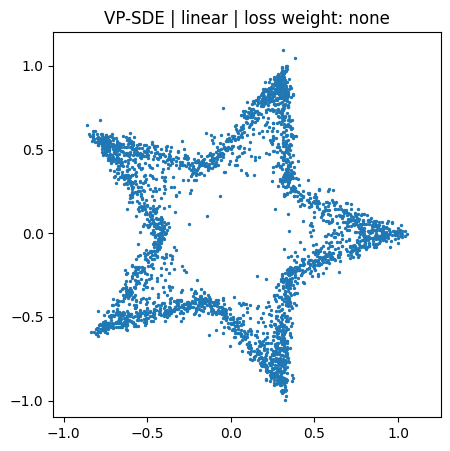

In [29]:
config = ExperimentConfig()
config.schedule_type = "linear"
config.loss_weight_type = "none"
config.epochs = 1500

trainer = VPExperimentTrainer(config)
losses = trainer.run()

samples = sample_vp_sde_experiment(trainer.model, config, num_samples=3000)

plt.figure(figsize=(5, 5))
plt.scatter(samples[:, 0], samples[:, 1], s=2)
plt.axis("equal")
plt.title("VP-SDE | linear | loss weight: none")
plt.show()

In [30]:
experiments = [
    ("linear", "none"),
    ("linear", "sigma2"),
    ("linear", "snr"),
    ("linear", "inverse_sigma2"),

    ("cosine", "none"),
    ("cosine", "sigma2"),
    ("cosine", "snr"),
    ("cosine", "inverse_sigma2"),
]

In [31]:
results = {}

for schedule_type, loss_weight_type in experiments:
    config = ExperimentConfig()
    config.schedule_type = schedule_type
    config.loss_weight_type = loss_weight_type
    config.epochs = 1500
    config.num_timesteps = 1500

    trainer = VPExperimentTrainer(config)
    losses = trainer.run()

    samples = sample_vp_sde_experiment(
        trainer.model,
        config,
        num_samples=3000
    )

    key = f"{schedule_type}_{loss_weight_type}"

    results[key] = {
        "config": config,
        "model": trainer.model,
        "losses": losses,
        "samples": samples
    }

Training: schedule=linear, loss_weight=none
Epoch 0, Loss: 1.708827
Epoch 100, Loss: 0.475186
Epoch 200, Loss: 0.443067
Epoch 300, Loss: 0.424509
Epoch 400, Loss: 0.422959
Epoch 500, Loss: 0.447163
Epoch 600, Loss: 0.432144
Epoch 700, Loss: 0.410581
Epoch 800, Loss: 0.413396
Epoch 900, Loss: 0.429397
Epoch 1000, Loss: 0.429239
Epoch 1100, Loss: 0.438727
Epoch 1200, Loss: 0.445455
Epoch 1300, Loss: 0.418468
Epoch 1400, Loss: 0.421278
Training: schedule=linear, loss_weight=sigma2
Epoch 0, Loss: 1.626449
Epoch 100, Loss: 0.158123
Epoch 200, Loss: 0.162500
Epoch 300, Loss: 0.154349
Epoch 400, Loss: 0.151960
Epoch 500, Loss: 0.156689
Epoch 600, Loss: 0.155361
Epoch 700, Loss: 0.153287
Epoch 800, Loss: 0.159597
Epoch 900, Loss: 0.154106
Epoch 1000, Loss: 0.152547
Epoch 1100, Loss: 0.149238
Epoch 1200, Loss: 0.154686
Epoch 1300, Loss: 0.157018
Epoch 1400, Loss: 0.151407
Training: schedule=linear, loss_weight=snr
Epoch 0, Loss: 1.846908
Epoch 100, Loss: 1.051230
Epoch 200, Loss: 1.105739
Epoch

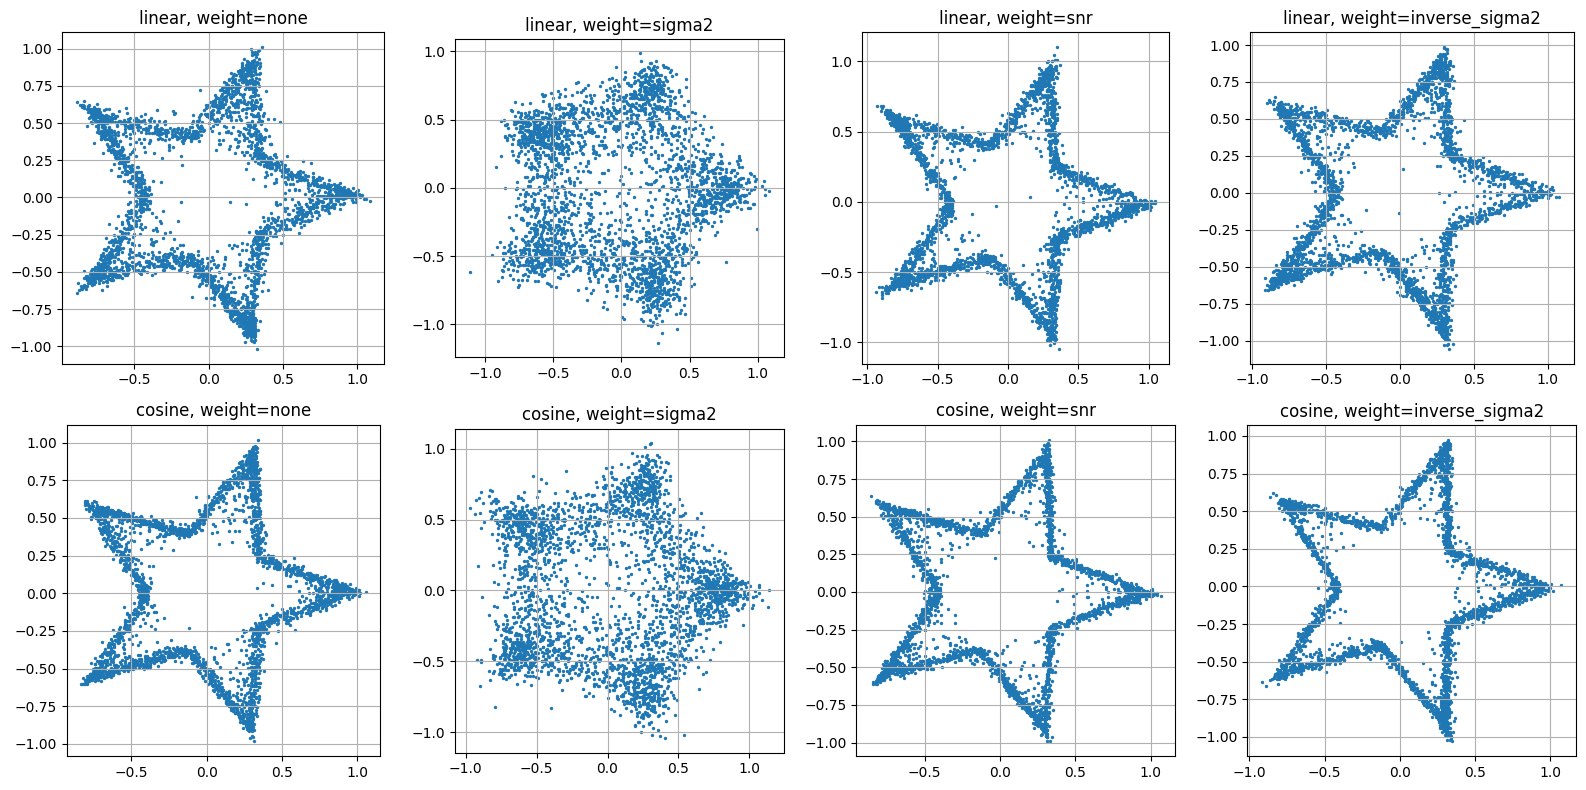

In [32]:
fig, axes = plt.subplots(2, 4, figsize=(16, 8))

for ax, (schedule_type, loss_weight_type) in zip(axes.ravel(), experiments):
    key = f"{schedule_type}_{loss_weight_type}"
    samples = results[key]["samples"]

    ax.scatter(samples[:, 0], samples[:, 1], s=2)
    ax.set_title(f"{schedule_type}, weight={loss_weight_type}")
    ax.set_aspect("equal")
    ax.grid(True)

plt.tight_layout()
plt.show()

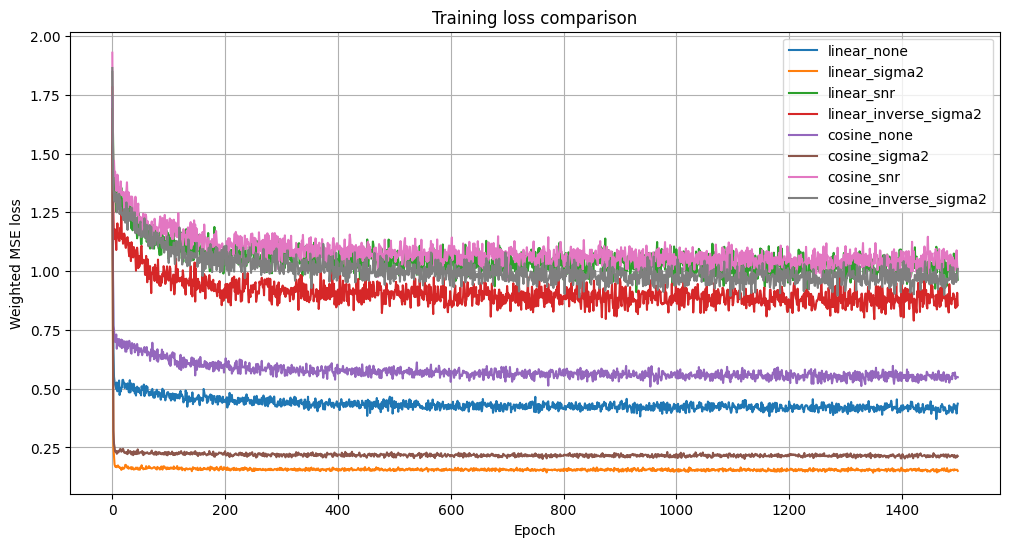

In [33]:
plt.figure(figsize=(12, 6))

for schedule_type, loss_weight_type in experiments:
    key = f"{schedule_type}_{loss_weight_type}"
    plt.plot(results[key]["losses"], label=key)

plt.title("Training loss comparison")
plt.xlabel("Epoch")
plt.ylabel("Weighted MSE loss")
plt.legend()
plt.grid()
plt.show()

In [ ]:
def nearest_distance_metric(samples, reference_points, batch_size=512):
    """
    Считает среднее расстояние от каждой сгенерированной точки
    до ближайшей настоящей точки звезды.
    """

    device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")

    samples_t = torch.tensor(samples, dtype=torch.float32, device=device)
    ref_t = torch.tensor(reference_points, dtype=torch.float32, device=device)

    distances = []

    with torch.no_grad():
        for i in range(0, samples_t.shape[0], batch_size):
            batch = samples_t[i:i + batch_size]
            dist = torch.cdist(batch, ref_t)
            min_dist = dist.min(dim=1).values
            distances.append(min_dist.cpu())

    distances = torch.cat(distances)

    return distances.mean().item()

In [35]:
reference_star = generate_star(n_samples=5000)

quality_scores = {}

for schedule_type, loss_weight_type in experiments:
    key = f"{schedule_type}_{loss_weight_type}"
    samples = results[key]["samples"]

    score = nearest_distance_metric(samples, reference_star)
    quality_scores[key] = score

quality_scores

{'linear_none': 0.03120475448668003,
 'linear_sigma2': 0.07643160223960876,
 'linear_snr': 0.024514157325029373,
 'linear_inverse_sigma2': 0.02691563405096531,
 'cosine_none': 0.023287924006581306,
 'cosine_sigma2': 0.07460653781890869,
 'cosine_snr': 0.018708953633904457,
 'cosine_inverse_sigma2': 0.018216319382190704}

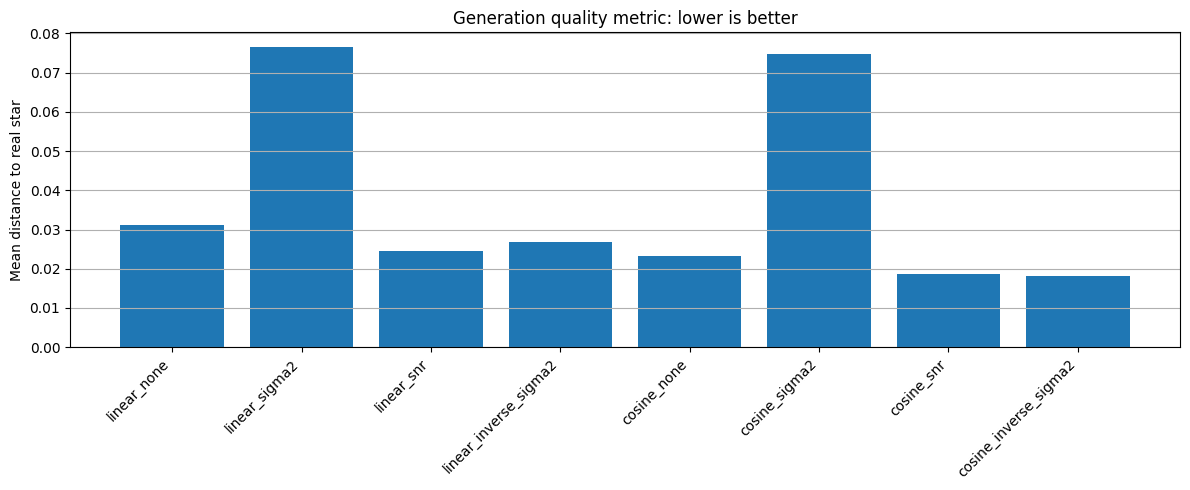

In [36]:
plt.figure(figsize=(12, 5))

names = list(quality_scores.keys())
values = list(quality_scores.values())

plt.bar(names, values)
plt.xticks(rotation=45, ha="right")
plt.ylabel("Mean distance to real star")
plt.title("Generation quality metric: lower is better")
plt.grid(axis="y")
plt.tight_layout()
plt.show()

По результатам экспериментов видно, что все рассмотренные варианты VP-SDE смогли восстановить общую форму звезды, однако качество генерации заметно зависит от расписания шума и способа перезвешивания функции потерь. Базовые варианты без перезвешивания дают рабочий результат, но контур остаётся более размытым, а часть точек попадает во внутреннюю область фигуры.

Наименее удачным оказался вариант с весом `sigma²`: несмотря на низкое значение loss, визуальное качество генерации хуже. Это связано с тем, что такое перезвешивание усиливает вклад сильно зашумлённых состояний, где геометрия звезды почти неразличима, поэтому модель хуже восстанавливает рёбра и вершины.

Лучшие результаты показали варианты `snr` и `inverse_sigma2`, так как они сильнее учитывают малые и средние уровни шума, где структура данных ещё сохраняется. По совокупности визуального сравнения и численной метрики наиболее удачными оказались варианты с косинусовым расписанием, особенно `cosine + snr` и `cosine + inverse_sigma2`. В целом лучшим и наиболее сбалансированным вариантом можно считать `cosine schedule + snr loss weighting`.
